In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.optimize import brentq, minimize_scalar
from dataclasses import dataclass

mpl.rcParams.update({
    "text.usetex": False,       # keep your sizes stable
    "mathtext.fontset": "cm",   # Computer Modern for math only
    # keep your normal font choice as-is (optional)
    # "font.family": "sans-serif",
    # "font.sans-serif": ["DejaVu Sans"],
})

## Fig 1. No feedback baseline (fixed game)

### Baseline game with no environmental feedback

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x} = x(1-x)(-(\alpha+\beta)x+\alpha)
\end{eqnarray}

#### Panel A. Stability diagram in the payoff-parameter space ($\alpha, \beta$)

In [2]:
# phase diagram
def classify(alpha, beta):
    """Output:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

A = np.linspace(-1, 1, 201)
B = np.linspace(-1, 1, 201)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

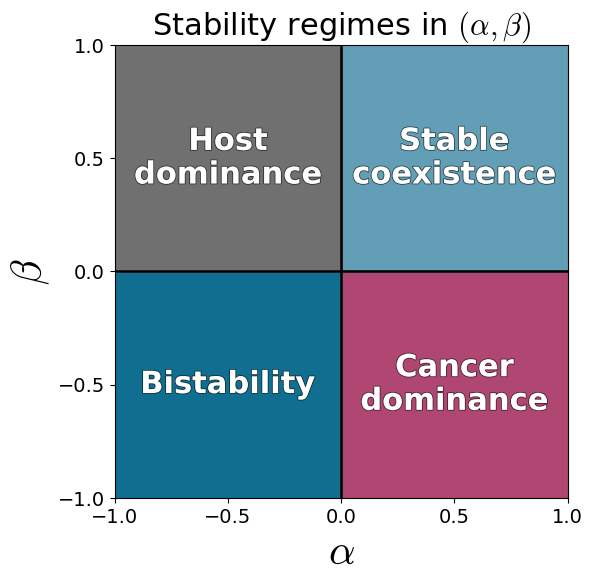

In [3]:
COL_HOST    = "#707071"   # host dominance
COL_COEX    = "#629FB7"   # stable coexistence
COL_BISTAB  = "#106E91"   # bistability
COL_CANCER  = "#AF4772"   # cancer dominance

# 0 host dom, 1 cancer dom, 2 coexist, 3 bistability
cmap = ListedColormap([COL_HOST, COL_CANCER, COL_COEX, COL_BISTAB])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

Z_masked = Z.astype(float)
Z_masked[Z_masked < 0] = np.nan  # hide alpha=0 or beta=0 cells

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(
    Z_masked,
    origin="lower",
    extent=[A.min(), A.max(), B.min(), B.max()],
    aspect="equal",
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

ax.axhline(0.001, linewidth=2, color='black')
ax.axvline(0, linewidth=2, color='black')
ax.set(xticks=np.arange(-1, 1.1, 0.5),
       yticks=np.arange(-1, 1.1, 0.5)
      )
ax.set_title(r'Stability regimes in $(\alpha,\beta)$',fontsize=22)
ax.set_xlabel(r'$\alpha$', fontsize=30)
ax.set_ylabel(r'$\beta$', fontsize=30)
ax.tick_params(axis='both', labelsize=14)

# text
txt_kw = dict(
    fontsize=22, color="white", ha="center", va="center", fontweight="semibold",
    path_effects=[pe.withStroke(linewidth=1.2, foreground=(0,0,0,0.6))]
)

ax.text(-0.5,  0.5, "Host\ndominance", **txt_kw)
ax.text( 0.5,  0.5, "Stable\ncoexistence", **txt_kw)
ax.text(-0.5, -0.5, "Bistability", **txt_kw)
ax.text( 0.5, -0.5, "Cancer\ndominance", **txt_kw)

plt.tight_layout()
plt.savefig('Figures/fig1A_phase_alpha_beta.png', dpi=600, bbox_inches="tight")
plt.savefig('Figures/fig1A_phase_alpha_beta.svg', bbox_inches="tight")
plt.show()

## Fig 2. $x(t)$ trajectories

In [4]:
def rhs(t, x, alpha, beta):
    x = x[0]
    dx = x*(1-x)*(alpha - (alpha+beta)*x)
    return [dx]

def sigammalate(alpha, beta, x0, tmax=60, npts=800):
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(rhs, (0, tmax), [x0], t_eval=t_eval,
                    args=(alpha, beta), rtol=1e-8, atol=1e-10)
    return sol.t, sol.y[0]

def x_star(alpha, beta):
    if alpha*beta > 0 and (alpha+beta) != 0:
        xs = alpha/(alpha+beta)
        if 0 < xs < 1:
            return xs
    return None

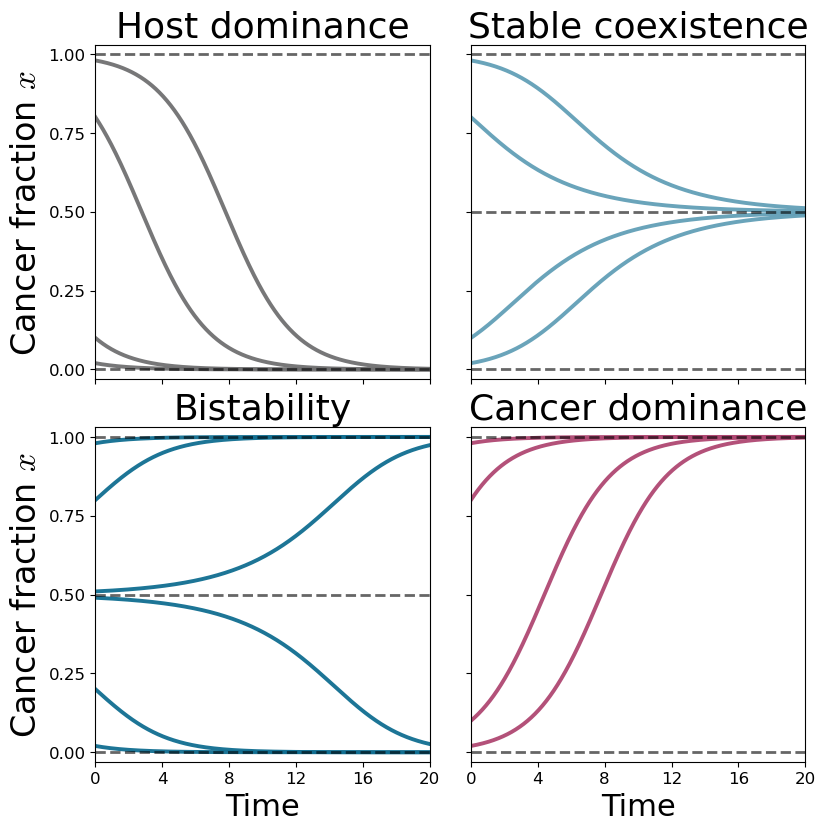

In [5]:
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Representative parameters (one per quadrant)
cases = [
    ("Host dominance",      -0.5, +0.5, COL["host"]),
    ("Stable coexistence",  +0.5, +0.5, COL["coexist"]),
    ("Bistability",         -0.5, -0.5, COL["bistab"]),
    ("Cancer dominance",    +0.5, -0.5, COL["cancer"]),
]
# Initial conditions (several to show convergence)
x0s_general = [0.02, 0.10, 0.80, 0.98]
# show both basins + "just below/above" the unstable point (~0.5 here)
x0s_bistab  = [0.02, 0.20, 0.49, 0.51, 0.80, 0.98]

# Make Panel B square overall, so each small panel can be square and still large
fig, axs = plt.subplots(2, 2, figsize=(8.2, 8.2), sharex=True, sharey=True, constrained_layout=True)
axs = axs.ravel()

for ax, (name, a, b, color) in zip(axs, cases):
    x0s = x0s_bistab if "Bistability" in name else x0s_general

    for x0 in x0s:
        t, x = sigammalate(a, b, x0, tmax=20)
        ax.plot(t, x, lw=2.8, color=color, alpha=0.95)

    # equilibrium guides (keep subtle)
    ax.axhline(0, ls="--", lw=2, color="black", alpha=0.6)
    ax.axhline(1, ls="--", lw=2, color="black", alpha=0.6)
    xs = x_star(a, b)
    if xs is not None:
        ax.axhline(xs, ls="--", lw=2, color="black", alpha=0.6)

    ax.set_title(name, fontsize=26, pad=6)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.03, 1.03)

    # square subplot boxes
    #ax.set_box_aspect(1)
    # square subplot boxes (new matplotlib if available; fallback otherwise)
    if hasattr(ax, "set_box_aspect"):
        ax.set_box_aspect(1)
    else:
        x0, x1 = ax.get_xlim()
        y0, y1 = ax.get_ylim()
        ax.set_aspect(abs((x1 - x0) / (y1 - y0)), adjustable='box')
    # integer-ish ticks on time, clean y ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(labelsize=12)

# axis labels (outer only)
axs[2].set_xlabel("Time", fontsize=22)
axs[3].set_xlabel("Time", fontsize=22)
axs[0].set_ylabel(r"Cancer fraction $x$", fontsize=24)
axs[2].set_ylabel(r"Cancer fraction $x$", fontsize=24)

plt.savefig("Figures/fig1B_trajectories.svg", bbox_inches="tight")
plt.savefig("Figures/fig1B_trajectories.png", dpi=600, bbox_inches="tight")

plt.show()


## Fig 4. Environmental feedback trajectories

In [7]:
# ----------------------------
# Core model building blocks
# ----------------------------

@dataclass(frozen=True)
class GameEndpoints:
    """
    Reduced 2x2 payoff form:
        M = [[0, beta],
             [alpha, 0]]

    Endpoints:
      (alpha_h, beta_h) = baseline (low conditioning)
      (alpha_s, beta_s) = stressed (high conditioning)
    """
    alpha_h: float
    beta_h: float
    alpha_s: float
    beta_s: float


def endpoints_host_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 1 mapping:
      baseline: host-dominant  (alpha<0, beta>0)
      stressed: cancer-dominant (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=-alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def endpoints_coexist_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 2 mapping:
      baseline: stable coexistence (alpha>0, beta>0)
      stressed: cancer-dominant    (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=+alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def hill_gate(n, k: float, nu: float = 1.0):
    """
    f(n) = n^nu / (n^nu + k^nu) in [0,1]
    Vectorized.
    """
    n = np.asarray(n)
    n = np.maximum(n, 0.0)
    return (n**nu) / (n**nu + k**nu)


def alpha_beta(n, ends: GameEndpoints, k: float, nu: float = 1.0):
    """
    alpha(n) and beta(n) via interpolation:
      alpha(n) = (1-f) alpha_h + f alpha_s
      beta(n)  = (1-f) beta_h  + f beta_s
    Returns alpha, beta, f (all vectorized).
    """
    f = hill_gate(n, k, nu)
    alpha_n = (1 - f) * ends.alpha_h + f * ends.alpha_s
    beta_n  = (1 - f) * ends.beta_h  + f * ends.beta_s
    return alpha_n, beta_n, f


def rhs(t, y, ends: GameEndpoints, phi: float, gamma: float, k: float, nu: float):
    """
    y = [x, n]
      xdot = x(1-x)( alpha(n) - (alpha(n)+beta(n)) x )
      ndot = phi*x - gamma*n
    """
    x, n = y

    # keep numerics sane
    x = np.clip(x, 0.0, 1.0)
    n = max(n, 0.0)

    a, b, _ = alpha_beta(n, ends, k, nu)
    dx = x * (1 - x) * (a - (a + b) * x)
    dn = phi * x - gamma * n
    return [dx, dn]


def simulate_case(ends: GameEndpoints,
                  phi: float, gamma: float, k: float, nu: float,
                  x0: float, n0: float,
                  tmax: float = 80.0, npts: int = 2000):
    """
    Returns a dict with:
      t, x, n, alpha(t), beta(t), f(t)
    """
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(
        rhs, (0, tmax), [x0, n0], t_eval=t_eval,
        args=(ends, phi, gamma, k, nu),
        rtol=1e-8, atol=1e-10
    )

    t = sol.t
    x = sol.y[0]
    n = sol.y[1]
    a, b, f = alpha_beta(n, ends, k, nu)

    return {"t": t, "x": x, "n": n, "alpha": a, "beta": b, "f": f}

# ----------------------------
# 4 default cases
# ----------------------------

@dataclass(frozen=True)
class Case:
    name: str
    ends: GameEndpoints
    phi: float
    gamma: float
    k: float
    nu: float
    tmax: float
    x0s: tuple
    n0: float


def build_default_cases():
    cases = {}

    # 1) Clearance (Scenario 1, rho_hat<1)
    cases["clearance"] = Case(
        name="Clearance",
        ends=endpoints_host_to_cancer(alpha=0.25, beta=0.5),
        phi=0.7, gamma=0.5, k=2.0, nu=1.0,
        tmax=80.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 2) Stable dormancy / persistence (Scenario 2, rho_hat<1)
    cases["dormancy"] = Case(
        name="Stable dormancy",
        ends=endpoints_coexist_to_cancer(alpha=0.5, beta=0.5),
        phi=0.7, gamma=1.0, k=2.0, nu=1.0,
        tmax=50.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 3) Awakening (Scenario 2, rho_hat>1)
    cases["awakening"] = Case(
        name="Awakening",
        ends=endpoints_coexist_to_cancer(alpha=0.1, beta=0.9),
        phi=0.09, gamma=0.02, k=2.0, nu=1.0,
        tmax=720.0,
        x0s=(0.02, 0.10, 0.40, 0.80),
        n0=0.0
    )

    # 4) Primed niche / invasion threshold (Scenario 1, rho_hat>1)
    # Show two initial conditions (your notebook: x0=0.2 vs 0.4)
    cases["primed_threshold"] = Case(
        name="Primed niche threshold",
        ends=endpoints_host_to_cancer(alpha=0.5, beta=0.6),
        phi=0.23, gamma=0.5, k=0.1, nu=1.0,
        tmax=50.0,
        x0s=(0.20, 0.40),
        n0=0.1
    )

    return cases

In [8]:
# Match Fig1 palette
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Choose one color per feedback case (feel free to change)
CASE_COLOR = {
    "clearance":        COL["host"],
    "dormancy":         COL["coexist"],
    "awakening":        COL["cancer"],
    "primed_threshold": COL["bistab"],
}

# Style knobs to match Fig1
LINE_W = 2.8
LINE_A = 0.95
DASH_W = 2.0
DASH_A = 0.6
TITLE_FS = 20
LABEL_FS = 20
XLABEL_FS = 18
TICK_FS = 12


def run_case(case, npts=2000):
    """Sigammalate all x0s for a Case. Returns list of dict outputs."""
    outs = []
    for x0 in case.x0s:
        out = simulate_case(
            case.ends,
            phi=case.phi, gamma=case.gamma, k=case.k, nu=case.nu,
            x0=x0, n0=case.n0,
            tmax=case.tmax, npts=npts
        )
        out["x0"] = x0
        outs.append(out)
    return outs


def _nice_ylim_n(case, outs):
    """Choose n-axis limits that always show 0 and the tolerance k line."""
    nmax = max(float(np.max(o["n"])) for o in outs)
    top = 1.05 * max(nmax, case.k)
    bottom = -0.03 * case.k  # tiny padding like your x axis
    return bottom, top


def plot_case_timeseries(case_key, case, outs, outdir="Figures",
                         layout="stack", label_x0=False):
    """
    Save ONE figure for ONE case.
    layout:
      - "stack": x(t) top, n(t) bottom
      - "twin" : x(t) left axis, n(t) right axis (same panel)
    """
    os.makedirs(outdir, exist_ok=True)
    color = CASE_COLOR.get(case_key, "black")

    if layout == "stack":
        fig, (ax_x, ax_n) = plt.subplots(
            2, 1, figsize=(6.2, 6.2), sharex=True, constrained_layout=True
        )

        # --- x(t) ---
        for o in outs:
            ax_x.plot(o["t"], o["x"], lw=LINE_W, color=color, alpha=LINE_A)
            if label_x0:
                ax_x.text(o["t"][int(0.03*len(o["t"]))], o["x"][int(0.03*len(o["x"]))],
                          f"{o['x0']:.2f}", fontsize=10, color=color)

        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)
        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)

        # --- n(t) ---
        for o in outs:
            ax_n.plot(o["t"], o["n"], lw=LINE_W, color=color, alpha=LINE_A)

        # tolerance line at n = k
        ax_n.axhline(case.k, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_n.set_ylabel(r"Conditioning $n$", fontsize=LABEL_FS)
        ax_n.set_xlabel("Time", fontsize=XLABEL_FS)
        nlo, nhi = _nice_ylim_n(case, outs)
        ax_n.set_ylim(nlo, nhi)

        # ticks (integer time, clean y)
        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        # Save
        base = os.path.join(outdir, f"fig3_{case_key}_{layout}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    elif layout == "twin":
        fig, ax_x = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax_n = ax_x.twinx()

        # x(t)
        for o in outs:
            ax_x.plot(o["t"], o["x"], lw=LINE_W, color=color, alpha=LINE_A)
        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)

        # n(t)
        for o in outs:
            ax_n.plot(o["t"], o["n"], lw=LINE_W, color="black", alpha=0.35)
        ax_n.axhline(case.k, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        nlo, nhi = _nice_ylim_n(case, outs)
        ax_n.set_ylim(nlo, nhi)

        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_xlabel("Time", fontsize=XLABEL_FS)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)
        ax_n.set_ylabel(r"Conditioning $n$", fontsize=LABEL_FS)

        ax_x.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    else:
        raise ValueError("layout gammast be 'stack' or 'twin'")

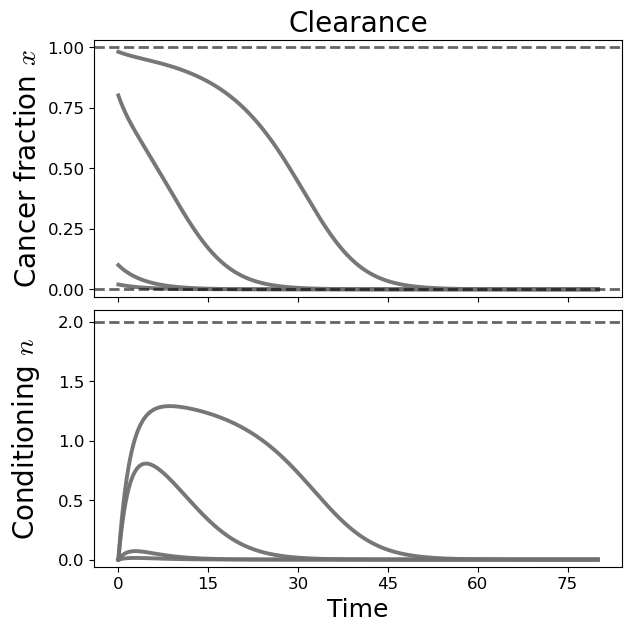

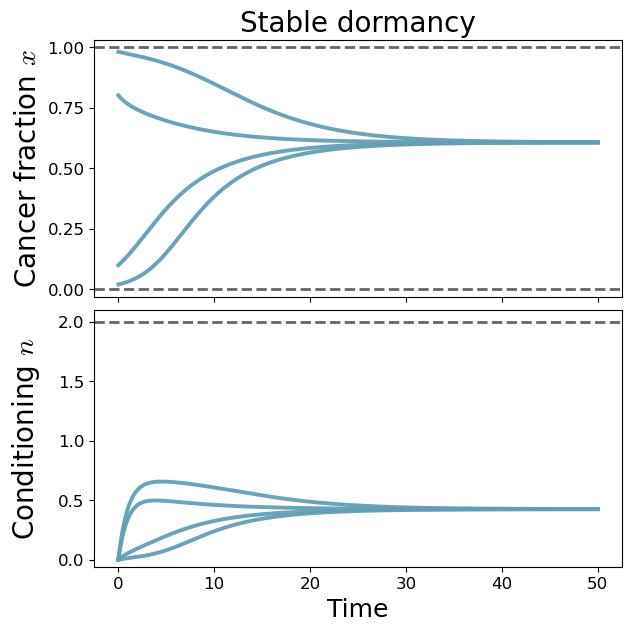

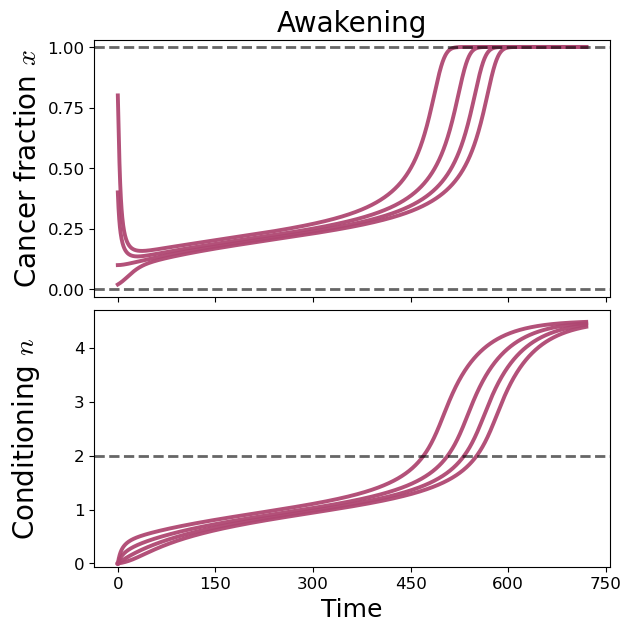

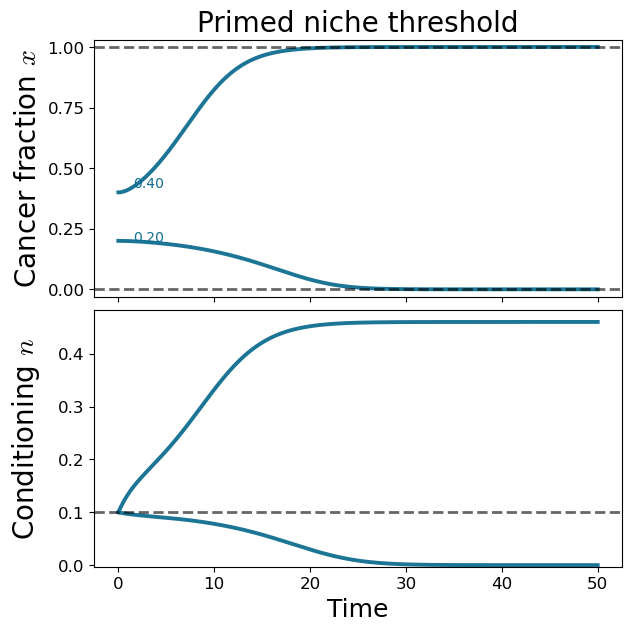

In [9]:
cases = build_default_cases()
all_outs = {}
# one-by-one (recommended)
for key in ["clearance", "dormancy", "awakening", "primed_threshold"]:
    case = cases[key]
    outs = run_case(case, npts=2000)
    all_outs[key] = outs
    # stacked plots (x above, n below)
    # layout = stack OR twin
    plot_case_timeseries(key, case, outs, outdir="Figures", layout="stack",
                         label_x0=(key == "primed_threshold"))

    # If twin-axis versions too:
    #plot_case_timeseries("awakening", cases["awakening"], run_case(cases["awakening"]),
    #                  outdir="Figures", layout="twin")


## Checking $\alpha$ and $\beta$ timeseries

Key = clearance
x0=0.02


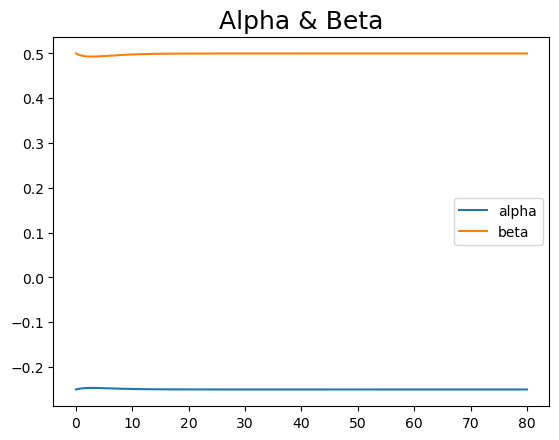

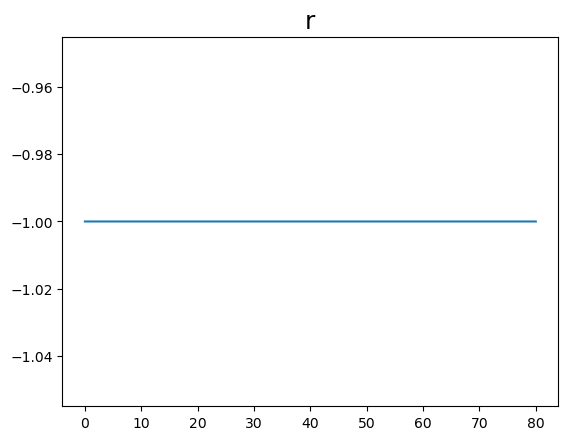

x0=0.1


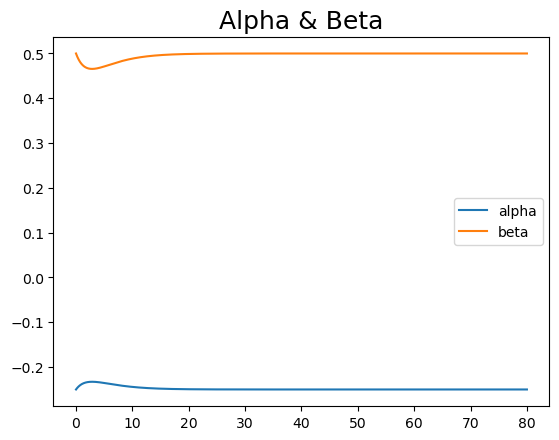

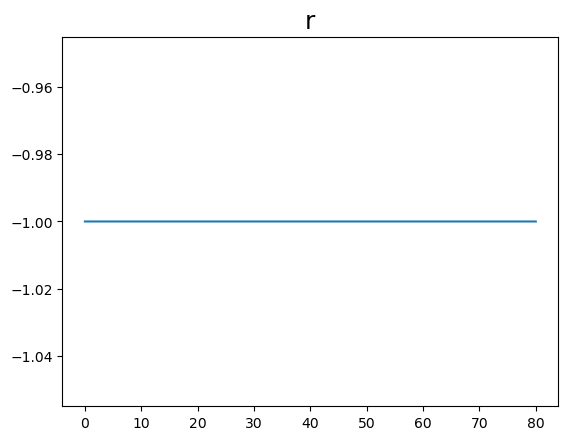

x0=0.8


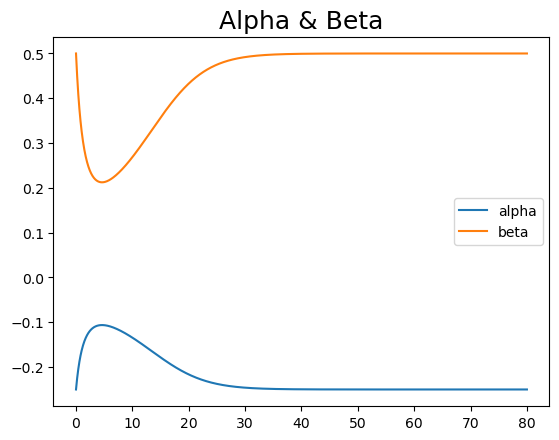

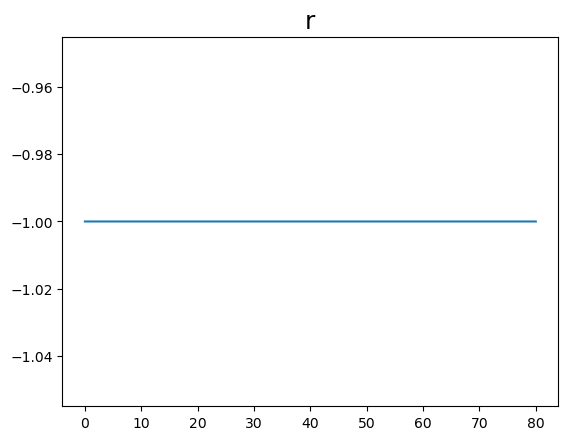

x0=0.98


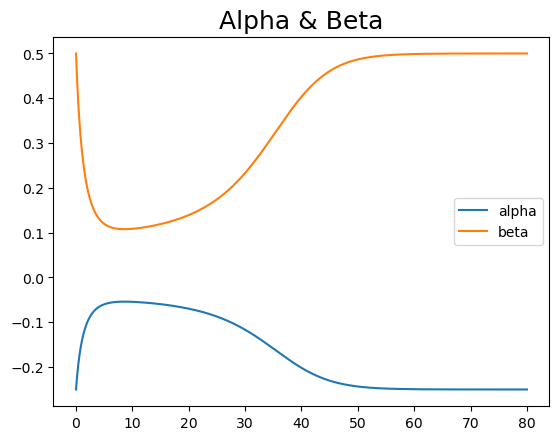

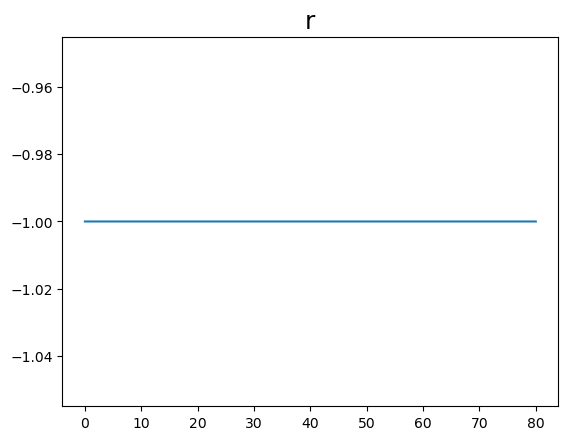

Key = dormancy
x0=0.02


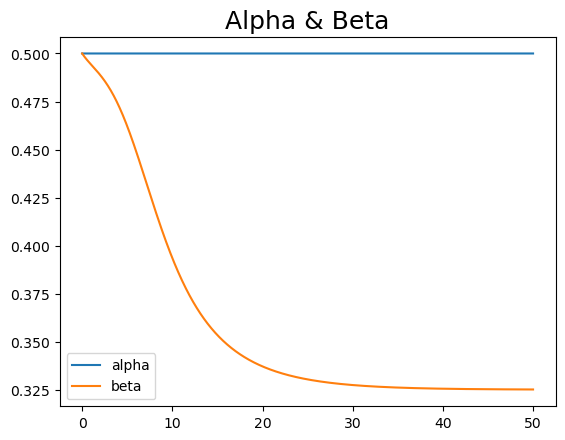

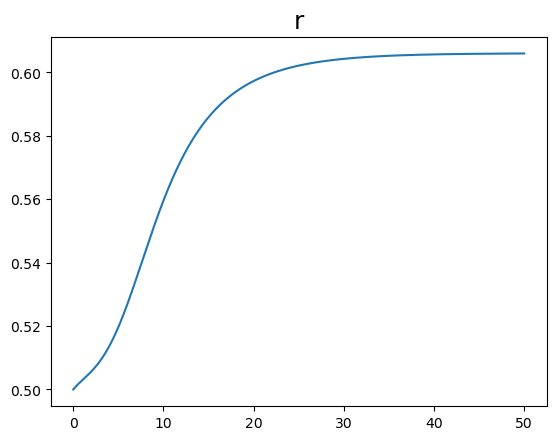

x0=0.1


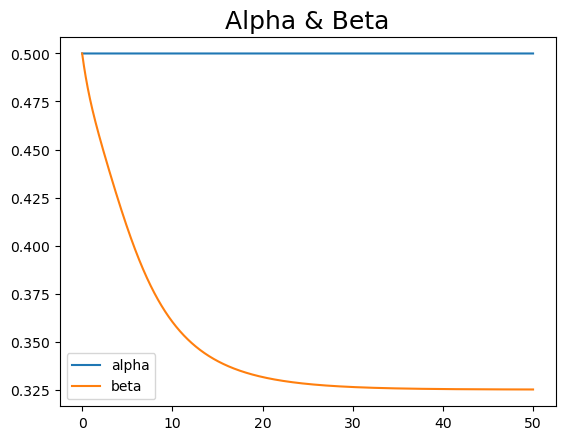

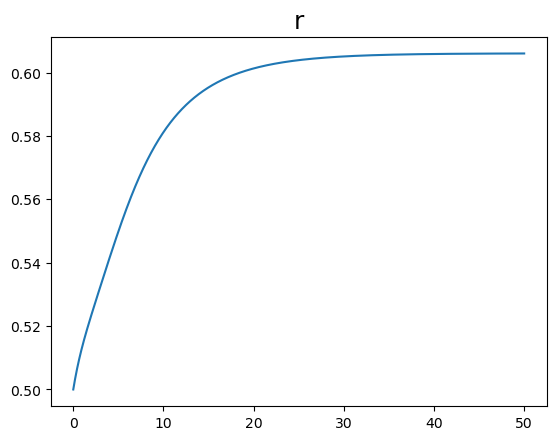

x0=0.8


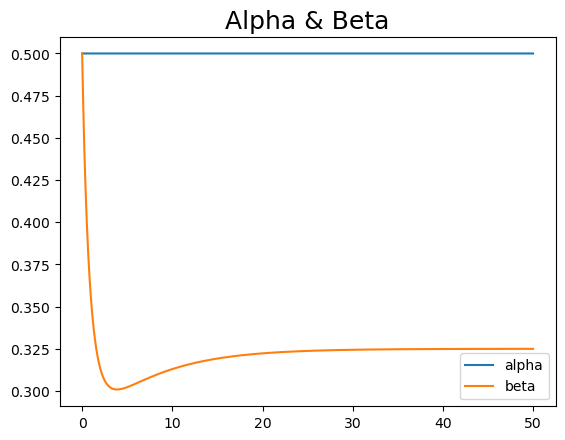

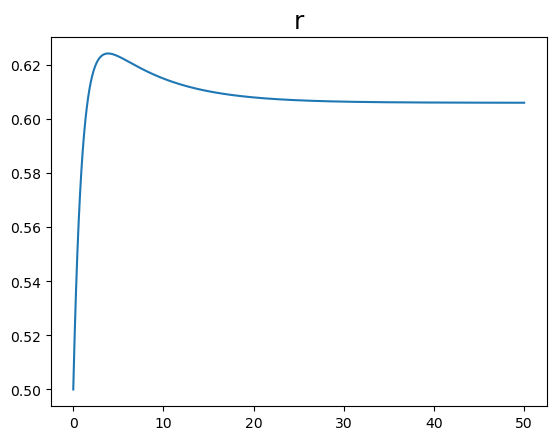

x0=0.98


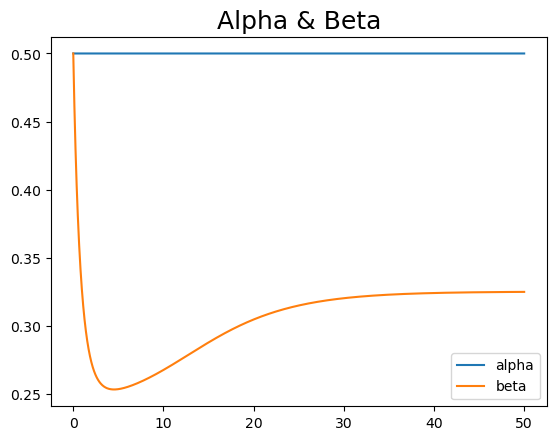

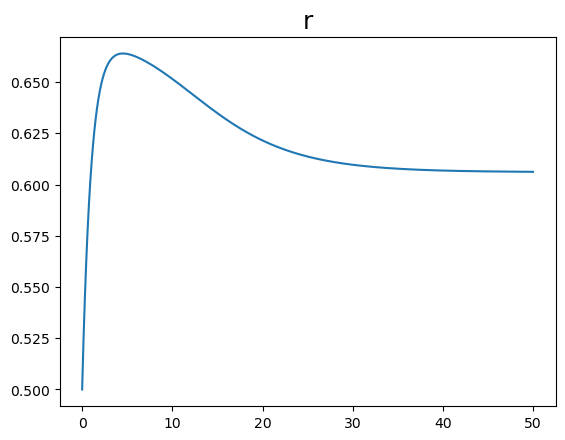

Key = awakening
x0=0.02


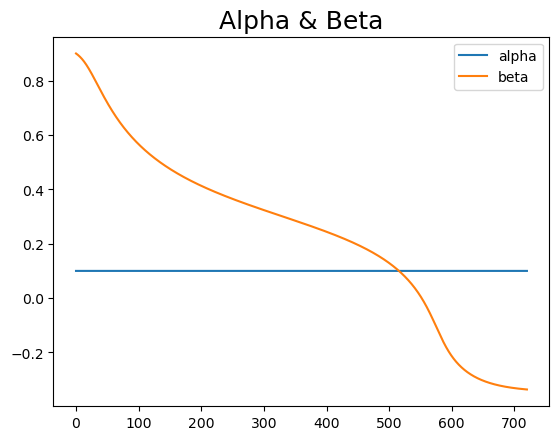

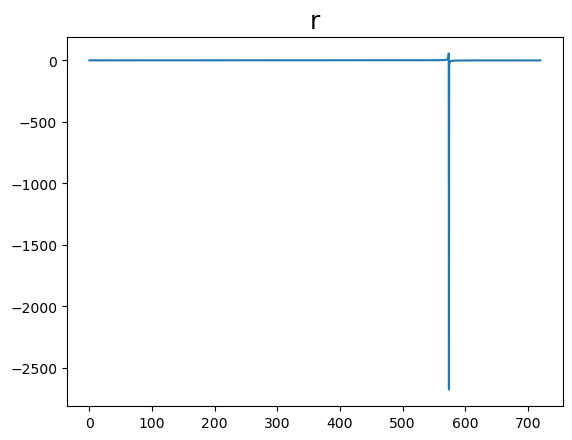

x0=0.1


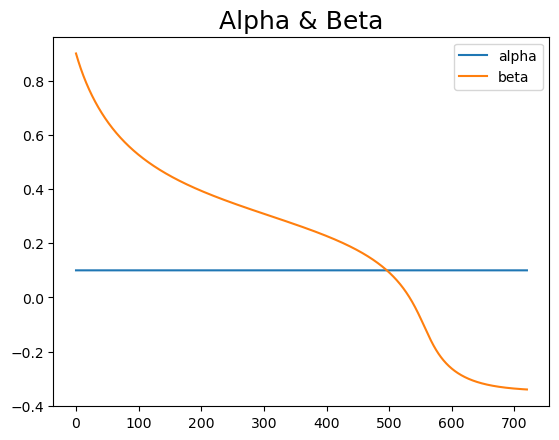

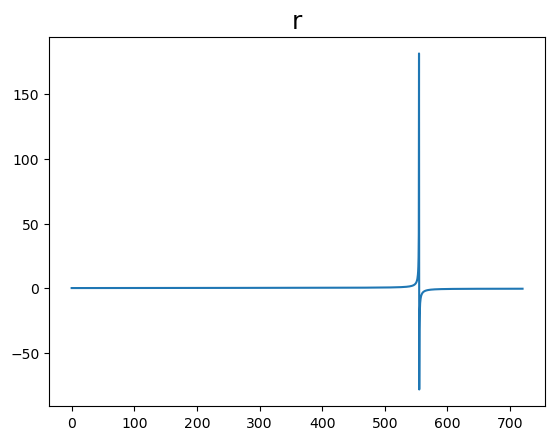

x0=0.4


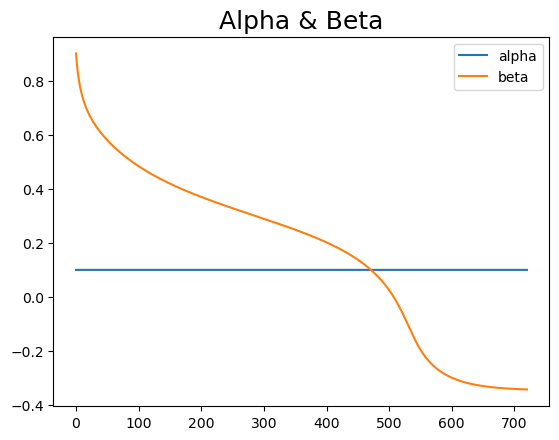

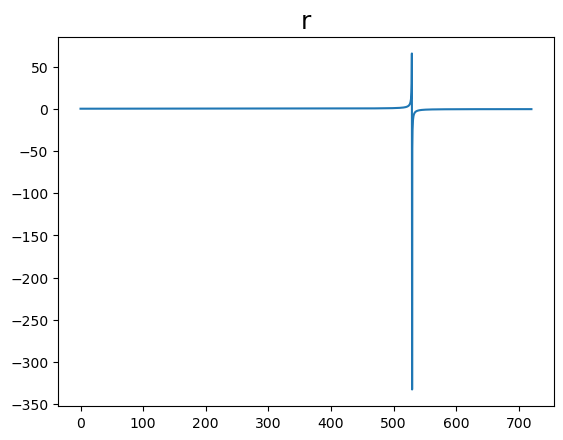

x0=0.8


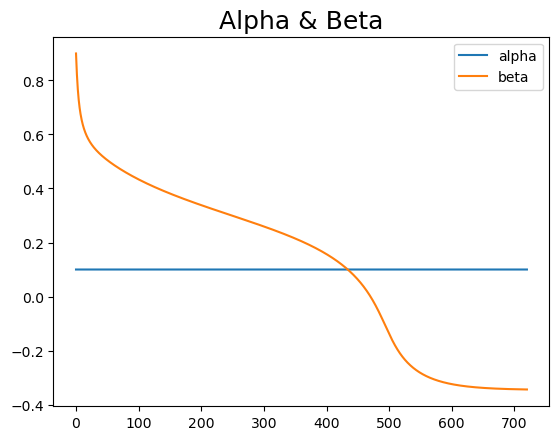

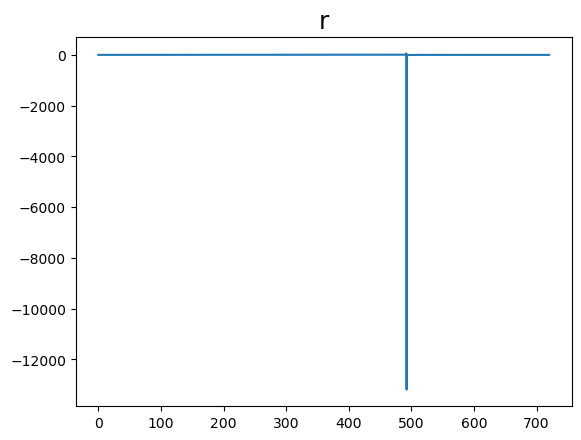

Key = primed_threshold
x0=0.2


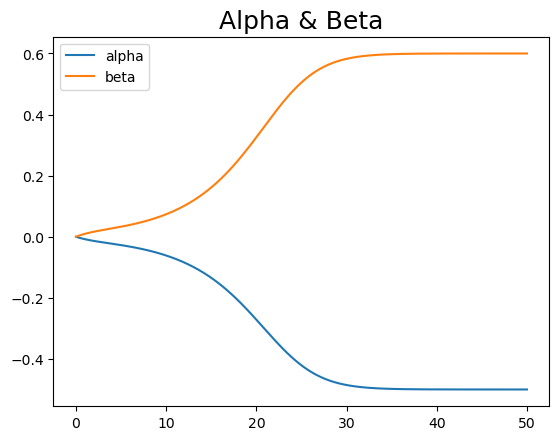

/tmp/ipykernel_5245/1876378300.py:11: RuntimeWarning: invalid value encountered in divide
  plt.plot(case['t'],case['alpha']/(case['alpha']+case['beta']))


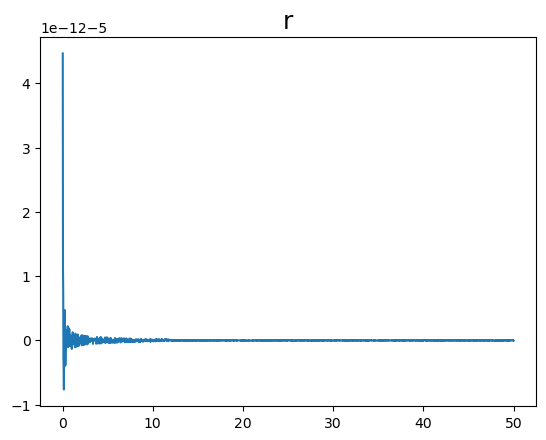

x0=0.4


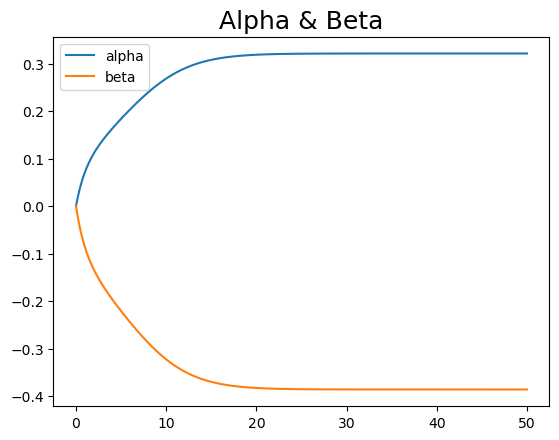

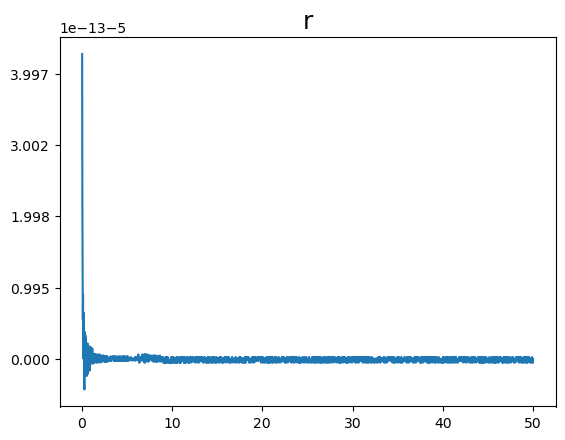

In [10]:
keys = ['clearance', 'dormancy', 'awakening', 'primed_threshold']
for key in keys:
    print(f"Key = {key}")
    for case in all_outs[key]:
        print(f"x0={case['x0']}")
        plt.plot(case['t'],case['alpha'], label='alpha')
        plt.plot(case['t'],case['beta'], label='beta')
        plt.title('Alpha & Beta',fontsize=18)
        plt.legend()
        plt.show()
        plt.plot(case['t'],case['alpha']/(case['alpha']+case['beta']))
        plt.title('r',fontsize=18)
        plt.show()

## Fig 4. (Nondimensional, reparametrized) Environmental feedback trajectories

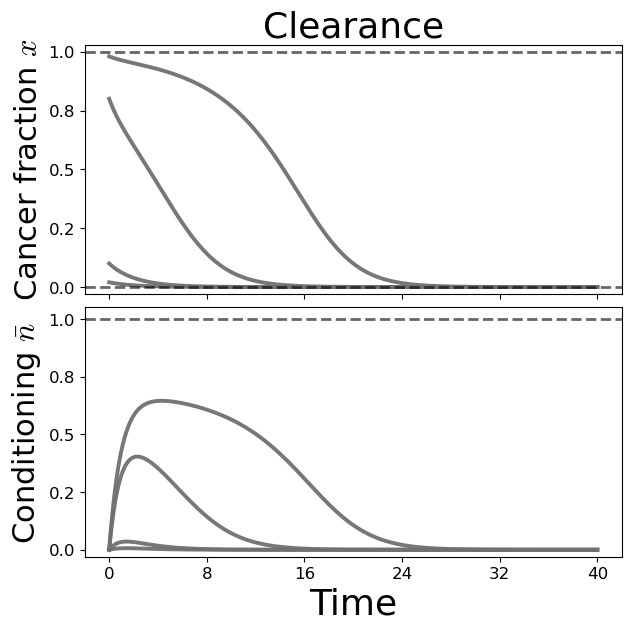

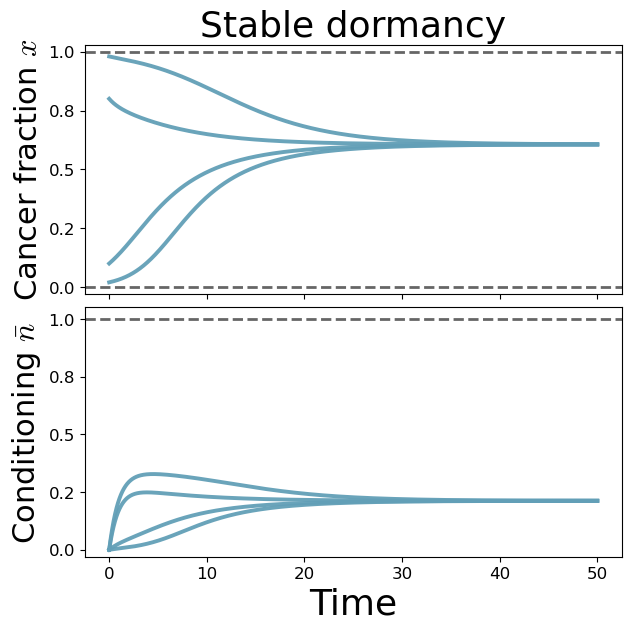

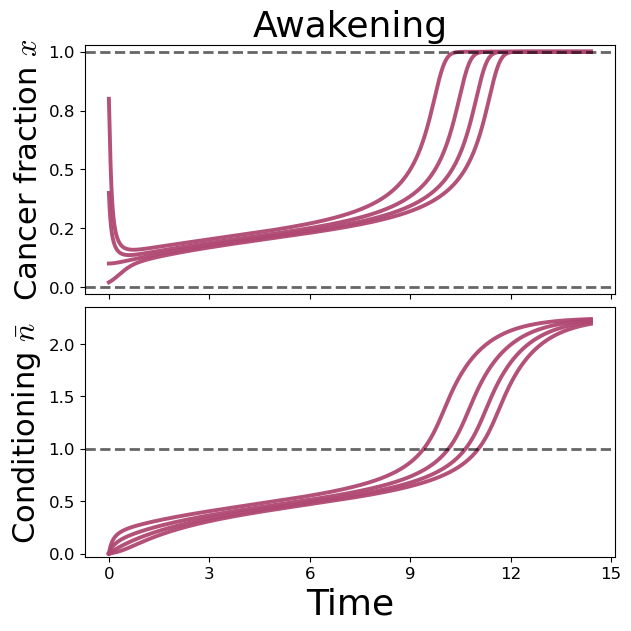

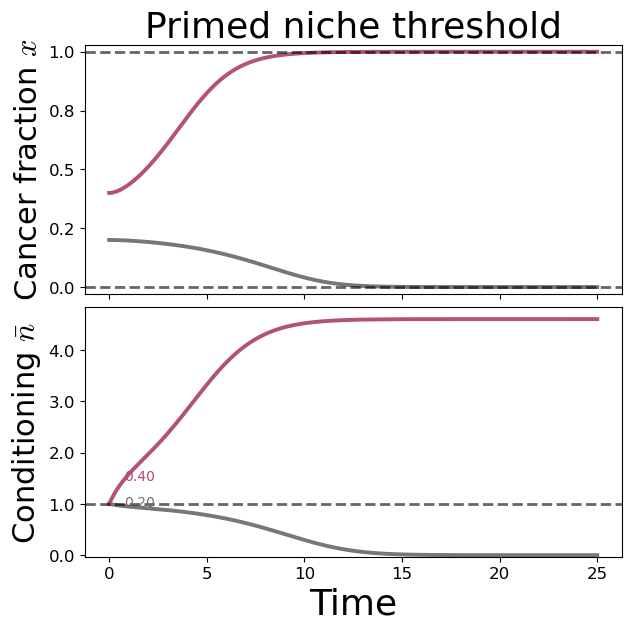

In [10]:
# ----------------------------
# Core model building blocks (NON-DIMENSIONAL STATE; INTEGRATE IN t)
#   state: (x, n̄) with n̄ = n/k
#   parameter: φ̄ = φ/(γ k)
#   integrate in dimensional t
#   option to plot either t or τ=γt
# ----------------------------

@dataclass(frozen=True)
class GameEndpoints:
    """
    Reduced 2x2 payoff-difference form:
        M = [[0, beta],
             [alpha, 0]]

    Endpoints:
      (alpha_h, beta_h) = baseline (low conditioning)
      (alpha_s, beta_s) = stressed  (high conditioning)
    """
    alpha_h: float
    beta_h: float
    alpha_s: float
    beta_s: float


def endpoints_host_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 1 mapping:
      baseline: host-dominant   (alpha<0, beta>0)
      stressed: cancer-dominant (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=-alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def endpoints_coexist_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 2 mapping:
      baseline: stable coexistence (alpha>0, beta>0)
      stressed: cancer-dominant    (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=+alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def hill_gate_bar(n_bar, nu: float = 1.0):
    """
    Non-dimensional Hill gate:
        f(n̄) = n̄^nu / (1 + n̄^nu)   in [0,1]
    Vectorized.
    """
    n_bar = np.asarray(n_bar)
    n_bar = np.maximum(n_bar, 0.0)
    return (n_bar**nu) / (1.0 + n_bar**nu)


def alpha_beta_bar(n_bar, ends: GameEndpoints, nu: float = 1.0):
    """
    alpha(n̄) and beta(n̄) via interpolation:
      alpha(n̄) = (1-f) alpha_h + f alpha_s
      beta(n̄)  = (1-f) beta_h  + f beta_s
    Returns alpha, beta, f (vectorized).
    """
    f = hill_gate_bar(n_bar, nu)
    alpha_n = (1 - f) * ends.alpha_h + f * ends.alpha_s
    beta_n  = (1 - f) * ends.beta_h  + f * ends.beta_s
    return alpha_n, beta_n, f


def rhs_t(t, y_bar, ends: GameEndpoints, phi_bar: float, gamma: float, nu: float):
    """
    Integrate in dimensional time t, but with non-dimensional conditioning state n̄=n/k.

      dx/dt     = x(1-x)[ alpha(n̄) - (alpha(n̄)+beta(n̄)) x ]
      dn̄/dt    = γ( φ̄ x - n̄ )     with φ̄ = φ/(γk)

    y_bar = [x, n̄]
    """
    x, n_bar = y_bar
    x = float(np.clip(x, 0.0, 1.0))
    n_bar = float(max(n_bar, 0.0))

    a, b, _ = alpha_beta_bar(n_bar, ends, nu)
    a = float(a); b = float(b)

    dx = x * (1 - x) * (a - (a + b) * x)
    dnbar = gamma * (phi_bar * x - n_bar)
    return [dx, dnbar]


def simulate_case_nondim(ends: GameEndpoints,
                         phi: float, gamma: float, k: float, nu: float,
                         x0: float, n0: float,
                         tmax: float = 80.0, npts: int = 2000):
    """
    Integrate the equations in dimensional time t, using n̄=n/k internally.
    Return both t and τ=γt, and both n̄ and n.

    Returns dict with:
      t, tau, x, nbar, n,
      alpha(t), beta(t), f(t),
      s(t)=alpha+beta, r(t)=alpha/s (NaN if s≈0),
      Lambda(t)=s/gamma, phi_bar
    """
    phi_bar = phi / (gamma * k)
    n0_bar = n0 / k

    t_eval = np.linspace(0.0, tmax, npts)

    sol = solve_ivp(
        rhs_t, (0.0, tmax), [x0, n0_bar],
        t_eval=t_eval,
        args=(ends, phi_bar, gamma, nu),
        rtol=1e-8, atol=1e-10
    )

    t = sol.t
    x = sol.y[0]
    nbar = sol.y[1]

    tau = gamma * t
    n = k * nbar

    a, b, f = alpha_beta_bar(nbar, ends, nu)
    s = a + b

    r = np.full_like(s, np.nan, dtype=float)
    mask = np.abs(s) > 1e-12
    r[mask] = a[mask] / s[mask]

    Lambda = s / gamma  # instantaneous selection/clearance ratio

    return {
        "t": t, "tau": tau,
        "x": x, "nbar": nbar, "n": n,
        "alpha": a, "beta": b, "f": f,
        "s": s, "r": r, "Lambda": Lambda,
        "phi_bar": phi_bar
    }


# ----------------------------
# 4 default cases (same API; phi_bar and nbar computed internally)
# ----------------------------

@dataclass(frozen=True)
class Case:
    name: str
    ends: GameEndpoints
    phi: float
    gamma: float
    k: float
    nu: float
    tmax: float
    x0s: tuple
    n0: float


def build_default_cases():
    cases = {}

    # 1) Clearance (Scenario 1, phi_bar < 1)
    cases["clearance"] = Case(
        name="Clearance",
        ends=endpoints_host_to_cancer(alpha=0.25, beta=0.5),
        phi=0.7, gamma=0.5, k=2.0, nu=1.0,
        tmax=80.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 2) Stable dormancy / persistence (Scenario 2, phi_bar < 1)
    cases["dormancy"] = Case(
        name="Stable dormancy",
        ends=endpoints_coexist_to_cancer(alpha=0.5, beta=0.5),
        phi=0.7, gamma=1.0, k=2.0, nu=1.0,
        tmax=50.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 3) Awakening (Scenario 2, phi_bar > 1)
    cases["awakening"] = Case(
        name="Awakening",
        ends=endpoints_coexist_to_cancer(alpha=0.1, beta=0.9),
        phi=0.09, gamma=0.02, k=2.0, nu=1.0,
        tmax=720.0,
        x0s=(0.02, 0.10, 0.40, 0.80),
        n0=0.0
    )

    # 4) Primed niche / invasion threshold (Scenario 1, phi_bar > 1)
    cases["primed_threshold"] = Case(
        name="Primed niche threshold",
        ends=endpoints_host_to_cancer(alpha=0.5, beta=0.6),
        phi=0.23, gamma=0.5, k=0.1, nu=1.0,
        tmax=50.0,
        x0s=(0.20, 0.40),
        n0=0.1
    )

    return cases


# ----------------------------
# Plot styling (match Fig1)
# ----------------------------

COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

CASE_COLOR = {
    "clearance":        COL["host"],
    "dormancy":         COL["coexist"],
    "awakening":        COL["cancer"],
    "primed_threshold": COL["bistab"],
}

LINE_W = 2.8
LINE_A = 0.95
DASH_W = 2.0
DASH_A = 0.6
TITLE_FS = 26
LABEL_FS = 22#20
XLABEL_FS = 26#18
TICK_FS = 12


def run_case(case: Case, npts=2000):
    """Simulate all x0s for a Case. Returns list of dict outputs."""
    outs = []
    for x0 in case.x0s:
        out = simulate_case_nondim(
            case.ends,
            phi=case.phi, gamma=case.gamma, k=case.k, nu=case.nu,
            x0=x0, n0=case.n0,
            tmax=case.tmax, npts=npts
        )
        out["x0"] = x0
        outs.append(out)
    return outs


def _nice_ylim_nbar(outs):
    """n̄-axis limits; always include 0 and show tolerance line at n̄=1."""
    nbar_max = max(float(np.max(o["nbar"])) for o in outs)
    top = 1.05 * max(nbar_max, 1.0)
    bottom = -0.03
    return bottom, top


def plot_case_timeseries(case_key, case: Case, outs, outdir="Figures",
                         layout="stack", time_axis="t", label_x0=False):
    """
    Save ONE figure for ONE case.

    layout:
      - "stack": x(top), n̄(bottom)
      - "twin" : x left axis, n̄ right axis (same panel)

    time_axis:
      - "t"   : dimensional time t
      - "tau" : scaled time τ = γ t
    """
    os.makedirs(outdir, exist_ok=True)
    color = CASE_COLOR.get(case_key, "black")

    def _T(o):
        return o["t"] if time_axis == "t" else o["tau"]

    def _curve_color(o):
        if case_key == "primed_threshold":
            # classify by final state (robust + zero extra bookkeeping)
            return COL["cancer"] if o["x"][-1] > 0.5 else COL["host"]
        return CASE_COLOR.get(case_key, "black")
    
    xlab = "Time" if time_axis == "t" else "Time"

    if layout == "stack":
        fig, (ax_x, ax_n) = plt.subplots(
            2, 1, figsize=(6.2, 6.2), sharex=True, constrained_layout=True
        )

        # --- x(t) ---
        for o in outs:
            c = _curve_color(o)
            ax_x.plot(_T(o), o["x"], lw=LINE_W, color=c, alpha=LINE_A)

        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)
        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)

        # --- n̄(t) ---
        for o in outs:
            c = _curve_color(o)
            ax_n.plot(_T(o), o["nbar"], lw=LINE_W, color=c, alpha=LINE_A)
            if label_x0:
                i = int(0.03 * len(_T(o)))
                ax_n.text(_T(o)[i], o["nbar"][i], f"{o['x0']:.2f}",
                          fontsize=10, color=c)

        ax_n.axhline(1.0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)  # tolerance at n̄=1
        ax_n.set_ylabel(r"Conditioning $\bar n$", fontsize=LABEL_FS)
        ax_n.set_xlabel(xlab, fontsize=XLABEL_FS)
        nlo, nhi = _nice_ylim_nbar(outs)
        ax_n.set_ylim(nlo, nhi)

        # ticks: integer-ish on x; fixed-format y to keep label widths aligned
        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_n.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}_{time_axis}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    elif layout == "twin":
        fig, ax_x = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax_n = ax_x.twinx()

        for o in outs:
            c = _curve_color(o)
            ax_x.plot(_T(o), o["x"], lw=LINE_W, color=c, alpha=LINE_A)
        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)

        for o in outs:
            c = _curve_color(o)
            ax_n.plot(_T(o), o["nbar"], lw=LINE_W, color="black", alpha=0.30)
        ax_n.axhline(1.0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        nlo, nhi = _nice_ylim_nbar(outs)
        ax_n.set_ylim(nlo, nhi)

        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_xlabel(xlab, fontsize=XLABEL_FS)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)
        ax_n.set_ylabel(r"Conditioning $\bar n$", fontsize=LABEL_FS)

        ax_x.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_n.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)
        fig.align_ylabels([ax_x, ax_n])

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}_{time_axis}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    else:
        raise ValueError("layout must be 'stack' or 'twin'.")


# -------------------------
# Example usage (one-by-one)
# -------------------------

cases = build_default_cases()

for key in ["clearance", "dormancy", "awakening", "primed_threshold"]:
    case = cases[key]
    outs = run_case(case, npts=2000)

    # Integrate in t, but choose what you plot on the x-axis here:
    plot_case_timeseries(
        key, case, outs,
        outdir="Figures",
        layout="stack",
        time_axis="tau",      # "t" or "tau"
        label_x0=(key == "primed_threshold")
    )


### Fig 5. Phase portraits

In [12]:
# ==========================================================
# Figure 5 — Phase portraits (2x2 + individual panels)
# Definitive, self-contained script:
#   - Removes nbar=1 line
#   - No panel letters A/B/C/D
#   - Saves 2x2 with ONE shared legend
#   - Saves each panel separately (no legend)
#   - Adds plot padding so fixed points/trajectories aren't clipped
#   - Uses add_arrows_to_line2D on Line2D trajectories
#   - Fixes spurious interior equilibrium/saddle by solving a continuous equation
# ==========================================================

In [13]:
# ----------------------------
# Colors (match Fig1 palette)
# ----------------------------
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

CASE_COLOR = {
    "clearance":        COL["host"],
    "dormancy":         COL["coexist"],
    "awakening":        COL["cancer"],
    "primed_threshold": COL["bistab"],
}


# ----------------------------
# Core model (non-dimensional state; integrate in tau = gamma t)
# ----------------------------
@dataclass(frozen=True)
class GameEndpoints:
    """
    Reduced payoff-difference form:
        M = [[0, beta],
             [alpha, 0]]

    Endpoints:
      (alpha_h, beta_h) = baseline (low conditioning)
      (alpha_s, beta_s) = stressed  (high conditioning)
    """
    alpha_h: float
    beta_h: float
    alpha_s: float
    beta_s: float


def endpoints_host_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 1 mapping:
      baseline: host-dominant   (alpha<0, beta>0)
      stressed: cancer-dominant (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=-alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def endpoints_coexist_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 2 mapping:
      baseline: stable coexistence (alpha>0, beta>0)
      stressed: cancer-dominant    (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=+alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


@dataclass(frozen=True)
class Case:
    name: str
    ends: GameEndpoints
    phi: float
    gamma: float
    k: float
    nu: float
    tmax: float
    x0s: tuple
    n0: float


def build_default_cases():
    cases = {}

    cases["clearance"] = Case(
        name="Clearance",
        ends=endpoints_host_to_cancer(alpha=0.25, beta=0.5),
        phi=0.7, gamma=0.5, k=2.0, nu=1.0,
        tmax=80.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    cases["dormancy"] = Case(
        name="Stable dormancy",
        ends=endpoints_coexist_to_cancer(alpha=0.5, beta=0.5),
        phi=0.7, gamma=1.0, k=2.0, nu=1.0,
        tmax=50.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    cases["awakening"] = Case(
        name="Awakening",
        ends=endpoints_coexist_to_cancer(alpha=0.1, beta=0.9),
        phi=0.09, gamma=0.02, k=2.0, nu=1.0,
        tmax=720.0,
        x0s=(0.02, 0.10, 0.40, 0.80),
        n0=0.0
    )

    cases["primed_threshold"] = Case(
        name="Primed niche threshold",
        ends=endpoints_host_to_cancer(alpha=0.5, beta=0.6),
        phi=0.23, gamma=0.5, k=0.1, nu=1.0,
        tmax=50.0,
        x0s=(0.20, 0.40),
        n0=0.1
    )

    return cases


def phi_bar(case: Case) -> float:
    """phi_bar = phi/(gamma*k)"""
    return case.phi / (case.gamma * case.k)


def hill_gate_bar(n_bar, nu: float = 1.0):
    """f(n̄) = n̄^nu / (1 + n̄^nu), vectorized, n̄>=0."""
    n_bar = np.asarray(n_bar)
    n_bar = np.maximum(n_bar, 0.0)
    return (n_bar**nu) / (1.0 + n_bar**nu)


def alpha_beta_bar(n_bar, ends: GameEndpoints, nu: float = 1.0):
    """Linear interpolation between endpoints via f(n̄)."""
    f = hill_gate_bar(n_bar, nu)
    alpha_n = (1 - f) * ends.alpha_h + f * ends.alpha_s
    beta_n  = (1 - f) * ends.beta_h  + f * ends.beta_s
    return alpha_n, beta_n, f


def rhs_tau(_tau, y, ends: GameEndpoints, phi_bar_val: float, gamma: float, nu: float):
    """
    tau = gamma t
      dx/dtau    = (1/gamma) x(1-x)[ a(nbar) - (a(nbar)+b(nbar)) x ]
      dnbar/dtau = phi_bar x - nbar
    """
    x, nbar = y
    x = float(np.clip(x, 0.0, 1.0))
    nbar = float(max(nbar, 0.0))

    a, b, _ = alpha_beta_bar(nbar, ends, nu)
    a = float(a); b = float(b)

    dx = (1.0 / gamma) * x * (1 - x) * (a - (a + b) * x)
    dn = phi_bar_val * x - nbar
    return [dx, dn]


def integrate_traj_tau(case: Case, x0: float, nbar0: float, tau_max=None, npts=1200):
    """Integrate one trajectory in tau and return arrays (tau, x(tau), nbar(tau))."""
    if tau_max is None:
        tau_max = case.gamma * case.tmax

    pb = phi_bar(case)
    tau_eval = np.linspace(0.0, tau_max, npts)

    sol = solve_ivp(
        rhs_tau, (0.0, tau_max), [x0, nbar0],
        t_eval=tau_eval,
        args=(case.ends, pb, case.gamma, case.nu),
        rtol=1e-8, atol=1e-10
    )
    return sol.t, sol.y[0], sol.y[1]


def x_nullcline_curve(case: Case, nbar_vals: np.ndarray, eps=1e-10):
    """
    Interior x-nullcline (dx=0):
        x = a(nbar)/(a(nbar)+b(nbar))
    Return x*(nbar) with NaNs where undefined/outside (0,1) or near singular.
    """
    a, b, _ = alpha_beta_bar(nbar_vals, case.ends, case.nu)
    s = a + b

    xstar = np.full_like(nbar_vals, np.nan, dtype=float)
    mask = np.abs(s) > eps
    xstar[mask] = (a[mask] / s[mask]).astype(float)

    xstar[(xstar <= 0.0) | (xstar >= 1.0)] = np.nan
    return xstar


def fprime_hill(nbar: float, nu: float) -> float:
    """Derivative of f(nbar)=nbar^nu/(1+nbar^nu)."""
    nbar = float(max(nbar, 0.0))
    return nu * (nbar ** (nu - 1.0)) / ((1.0 + nbar ** nu) ** 2)


def jacobian_tau(case: Case, x: float, nbar: float) -> np.ndarray:
    """
    Jacobian of tau-system:
      F = dx/dtau = (1/gamma)*x(1-x)[a - (a+b)x]
      G = dnbar/dtau = phi_bar*x - nbar
    """
    pb = phi_bar(case)
    gamma = case.gamma
    nu = case.nu
    ends = case.ends

    a, b, _ = alpha_beta_bar(nbar, ends, nu)
    a = float(a); b = float(b)

    p = x * (1.0 - x)
    q = a - (a + b) * x
    dp = 1.0 - 2.0 * x
    dq = -(a + b)
    Fx = (1.0 / gamma) * (dp * q + p * dq)

    fp = fprime_hill(nbar, nu)
    a_n = fp * (ends.alpha_s - ends.alpha_h)
    b_n = fp * (ends.beta_s  - ends.beta_h)
    s_n = a_n + b_n

    dq_n = a_n - s_n * x
    Fn = (1.0 / gamma) * (p * dq_n)

    Gx = pb
    Gn = -1.0

    return np.array([[Fx, Fn], [Gx, Gn]], dtype=float)


def classify_equilibrium(case: Case, x: float, nbar: float, tol=1e-8) -> str:
    eig = np.linalg.eigvals(jacobian_tau(case, x, nbar))
    re = np.real(eig)
    if np.all(re < -tol):
        return "stable"
    if np.all(re > tol):
        return "unstable"
    if re[0] * re[1] < -tol:
        return "saddle"
    return "neutral"


# ----------------------------
# CRITICAL FIX: interior equilibria without discontinuity
# ----------------------------
def find_interior_equilibria(case: Case):
    """
    Interior equilibria satisfy:
      nbar = pb*x
      and dx=0 interior:  a(nbar) - (a(nbar)+b(nbar))x = 0

    Equivalent continuous equation (no division):
      h(x) = x*(a+b) - a = 0, evaluated at nbar=pb*x.
    """
    pb = phi_bar(case)
    ends = case.ends
    nu = case.nu

    def h(x):
        if not (0.0 < x < 1.0):
            return np.nan
        nbar = pb * x
        a, b, _ = alpha_beta_bar(nbar, ends, nu)
        a = float(a); b = float(b)
        return x * (a + b) - a

    xs = np.linspace(1e-6, 1.0 - 1e-6, 8000)
    hv = np.array([h(x) for x in xs], dtype=float)

    roots = []
    for i in range(len(xs) - 1):
        h1, h2 = hv[i], hv[i + 1]
        if np.isnan(h1) or np.isnan(h2):
            continue
        if h1 == 0.0:
            roots.append(xs[i])
            continue
        if h1 * h2 < 0.0:
            try:
                r = brentq(h, xs[i], xs[i + 1], maxiter=200)
                roots.append(float(r))
            except Exception:
                pass

    if len(roots) == 0:
        res = minimize_scalar(lambda z: abs(h(z)), bounds=(1e-6, 1.0 - 1e-6), method="bounded")
        if res.success and abs(h(res.x)) < 1e-9:
            roots.append(float(res.x))

    roots = sorted(roots)
    uniq = []
    for r in roots:
        if not uniq or abs(r - uniq[-1]) > 1e-5:
            uniq.append(r)

    return [(r, pb * r) for r in uniq]


def compute_equilibria(case: Case):
    pb = phi_bar(case)
    eqs = [
        {"x": 0.0, "nbar": 0.0},
        {"x": 1.0, "nbar": pb},
    ]
    for (xI, nI) in find_interior_equilibria(case):
        eqs.append({"x": xI, "nbar": nI})
    for e in eqs:
        e["kind"] = classify_equilibrium(case, e["x"], e["nbar"])
    return eqs


# ----------------------------
# Arrow helper (your version)
# ----------------------------
def add_arrows_to_line2D(line, n_arrows=3, arrowstyle='->', lw=1):
    """
    Add `n_arrows` arrows along a 2D line (Line2D object from plt.plot).
    Arrows are approximately equally spaced by arc length.
    """
    ax = line.axes
    x = line.get_xdata()
    y = line.get_ydata()
    color = line.get_color()

    N = len(x)
    if N < 2:
        return

    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate(([0.0], np.cumsum(ds)))

    if s[-1] == 0:
        return

    s_norm = s / s[-1]
    targets = np.linspace(0.2, 0.8, n_arrows)

    for t in targets:
        idx = np.searchsorted(s_norm, t)
        if idx <= 0 or idx >= N:
            continue

        x_start, y_start = x[idx-1], y[idx-1]
        x_end,   y_end   = x[idx],   y[idx]

        ax.annotate(
            "",
            xy=(x_end, y_end), xytext=(x_start, y_start),
            arrowprops=dict(
                arrowstyle=arrowstyle,
                color=color,
                lw=lw,
                shrinkA=0,
                shrinkB=0,
            ),
        )


# ----------------------------
# Basin shading for bistable case (fast Euler)
# ----------------------------
def basin_map_euler(case: Case, ylim, nx=151, ny=151, tau_end=None, dtau=0.02):
    pb = phi_bar(case)
    if tau_end is None:
        tau_end = case.gamma * case.tmax

    xs = np.linspace(0.0, 1.0, nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys)

    x = X.copy()
    nbar = Y.copy()

    steps = int(tau_end / dtau)
    ends = case.ends
    nu = case.nu
    gamma = case.gamma

    for _ in range(steps):
        a, b, _ = alpha_beta_bar(nbar, ends, nu)
        dx = (1.0 / gamma) * x * (1 - x) * (a - (a + b) * x)
        dn = pb * x - nbar

        x = np.clip(x + dtau * dx, 0.0, 1.0)
        nbar = np.maximum(nbar + dtau * dn, 0.0)

    Z = (x > 0.5).astype(float)  # 1=cancer basin, 0=host basin
    return X, Y, Z


# ----------------------------
# Shared legend handles (NO nbar=1)
# ----------------------------
def common_fig4_legend_handles(include_basin_items=True):
    handles = [
        #Line2D([0],[0], color="black", ls="--", lw=2.0, alpha=0.6,
        #       label=r"$\dot{\bar n}=0$  ($\bar n=\bar\phi x$)"),
        #Line2D([0],[0], color="black", ls="-", lw=2.0, alpha=0.85,
        #       label=r"$\dot x=0$ (interior)"),
        Line2D([0],[0], marker="o", color="none",
               markerfacecolor="white", markeredgecolor="black",
               markeredgewidth=1.5, markersize=7,
               label="initial condition"),
        Line2D([0],[0], marker="o", color="none",
               markerfacecolor="black", markeredgecolor="white",
               markeredgewidth=1.5, markersize=8,
               label="stable equilibrium"),
        Line2D([0],[0], marker="*", color="none",
               markerfacecolor="black", markeredgecolor="black",
               markersize=12,
               label="saddle"),
        Line2D([0],[0], color="black", lw=2.5, alpha=0.9,
               label="trajectories"),
    ]
    if include_basin_items:
        handles += [
            Line2D([0],[0], color="black", lw=2.2, label="separatrix"),
            Line2D([0],[0], color=COL["host"],   lw=3, alpha=0.8, label="host basin"),
            Line2D([0],[0], color=COL["cancer"], lw=3, alpha=0.8, label="cancer basin"),
        ]
    return handles


# ----------------------------
# Main single-panel plotter
# ----------------------------
def plot_phase_portrait(
    ax,
    case_key: str,
    case: Case,
    *,
    quiver_n=(23, 23),
    nbar_ylim=None,
    n_ic=14,
    seed=1,
    compute_basins_for_bistable=True,
    xpad=0.04,
    ypad_frac=0.06,
):
    pb = phi_bar(case)

    # y-range for computations (>=0)
    if nbar_ylim is None:
        ymax = max(1.2, 1.15 * max(1.0, pb))
        nbar_ylim_data = (0.0, ymax)
    else:
        nbar_ylim_data = (max(0.0, float(nbar_ylim[0])), float(nbar_ylim[1]))

    # y-range for plotting (padding; can dip slightly below 0)
    ylow_plot = -ypad_frac * nbar_ylim_data[1]
    yhigh_plot = nbar_ylim_data[1] * (1.0 + ypad_frac)

    # basins + separatrix only for primed_threshold
    if compute_basins_for_bistable and case_key == "primed_threshold":
        Xg, Yg, Z = basin_map_euler(case, nbar_ylim_data, nx=151, ny=151, dtau=0.02)
        ax.contourf(Xg, Yg, Z, levels=[-0.5, 0.5, 1.5],
                    colors=[COL["host"], COL["cancer"]], alpha=0.12)
        ax.contour(Xg, Yg, Z, levels=[0.5], colors="black", linewidths=2.2, alpha=0.9)

    # vector field (normalized direction)
    xq = np.linspace(0.02, 0.98, quiver_n[0])
    yq = np.linspace(nbar_ylim_data[0], nbar_ylim_data[1], quiver_n[1])
    X, Y = np.meshgrid(xq, yq)

    a, b, _ = alpha_beta_bar(Y, case.ends, case.nu)
    dx = (1.0 / case.gamma) * X * (1 - X) * (a - (a + b) * X)
    dn = pb * X - Y

    speed = np.sqrt(dx * dx + dn * dn)
    dxn = np.where(speed > 0, dx / speed, 0.0)
    dnn = np.where(speed > 0, dn / speed, 0.0)

    ax.quiver(X, Y, dxn, dnn,
              angles="xy", scale_units="xy", scale=35,
              width=0.003, headwidth=3.5, headlength=4.5, headaxislength=4.0,
              color="black", alpha=0.6)

    # nullclines
    """
    xx = np.linspace(0.0, 1.0, 600)
    ax.plot(xx, pb * xx, ls="--", lw=2.0, color="black", alpha=0.6)  # dnbar=0

    nvals = np.linspace(nbar_ylim_data[0], nbar_ylim_data[1], 800)
    xstar = x_nullcline_curve(case, nvals)
    ax.plot(xstar, nvals, lw=2.0, color="black", alpha=0.85)         # dx=0 interior
    """
    # equilibria
    eqs = compute_equilibria(case)
    for e in eqs:
        xeq, yeq, kind = e["x"], e["nbar"], e["kind"]
        if kind == "stable":
            ax.plot(xeq, yeq, marker="o", ms=9, mfc="black", mec="white", mew=1.5, linestyle="None", zorder=7)
        elif kind == "saddle":
            ax.plot(xeq, yeq, marker="*", ms=14, mfc="black", mec="black", linestyle="None", zorder=8)
        elif kind == "unstable":
            ax.plot(xeq, yeq, marker="o", ms=9, mfc="white", mec="black", mew=1.5, linestyle="None", zorder=7)

    # trajectories
    rng = np.random.default_rng(seed)
    xs0 = rng.uniform(0.05, 0.95, size=n_ic)
    ys0 = rng.uniform(nbar_ylim_data[0] + 0.02, nbar_ylim_data[1] - 0.02, size=n_ic)

    # deterministic ICs
    extra_x = np.array([0.1, 0.9, 0.5, 0.2, 0.8])
    extra_y = np.array([0.0, 0.0, min(1.0, nbar_ylim_data[1]-0.02), 0.2,
                        min(nbar_ylim_data[1] * 0.8, nbar_ylim_data[1]-0.02)])
    xs0 = np.concatenate([xs0, extra_x])
    ys0 = np.concatenate([ys0, extra_y])

    tau_max = case.gamma * case.tmax
    base_color = CASE_COLOR.get(case_key, "black")

    for (x0, y0) in zip(xs0, ys0):
        _, xt, nt = integrate_traj_tau(case, float(x0), float(y0), tau_max=tau_max, npts=1200)

        c = base_color
        if case_key == "primed_threshold":
            c = COL["cancer"] if xt[-1] > 0.5 else COL["host"]

        line = ax.plot(xt, nt, lw=2.2, color=c, alpha=0.92, zorder=5)[0]
        add_arrows_to_line2D(line, n_arrows=2, arrowstyle="->", lw=1.6)

        ax.plot(xt[0], nt[0], marker="o", ms=5, mfc="white", mec=c, mew=1.4, linestyle="None", zorder=6)

    # formatting + padding
    ax.set_xlim(-xpad, 1.0 + xpad)
    ax.set_ylim(ylow_plot, yhigh_plot)
    ax.set_title(case.name, fontsize=18, pad=6)
    ax.set_xlabel(r"Cancer fraction $x$", fontsize=14)
    ax.set_ylabel(r"Conditioning $\bar n$", fontsize=14)
    ax.tick_params(labelsize=11)

def enforce_square_axes(axs):
    """Force every axis box to be square."""
    for ax in np.ravel(axs):
        # modern Matplotlib
        if hasattr(ax, "set_box_aspect"):
            ax.set_box_aspect(1)
        else:
            make_axes_box_square(ax)


def make_axes_box_square(ax):
    """
    Force the *axes box* (panel) to be square in figure coordinates.
    Fallback for older matplotlib.
    """
    fig = ax.figure
    fig.canvas.draw()  # finalize positions
    b = ax.get_position()
    s = min(b.width, b.height)
    cx = 0.5 * (b.x0 + b.x1)
    cy = 0.5 * (b.y0 + b.y1)
    ax.set_position([cx - s/2, cy - s/2, s, s])
    
# ----------------------------
# Build the 2x2 figure + individual panels
# ----------------------------
def plot_fig4_phase_portraits(
    cases: dict,
    outdir="Figures",
    filename_base="fig4_phase_portraits",
    include_basin_items=True,
    save_individual=True,
):
    os.makedirs(outdir, exist_ok=True)
    order = ["clearance", "dormancy", "awakening", "primed_threshold"]

    # --- 2x2 with shared legend ---
    # Make the FIGURE square so square panels are actually feasible.
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    for ax, key in zip(axs.ravel(), order):
        plot_phase_portrait(
            ax, key, cases[key],
            n_ic=14,
            seed=1,
            compute_basins_for_bistable=True,
        )

    # Make all panels square AFTER plotting and BEFORE any layout/legend.
    enforce_square_axes(axs)

    # Manual spacing (DO NOT use tight_layout here; it breaks box_aspect)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.22,
                        wspace=0.28, hspace=0.28)

    # Shared legend
    handles = common_fig4_legend_handles(include_basin_items=include_basin_items)
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=4,
        frameon=True,
        fontsize=9,
        bbox_to_anchor=(0.5, 0.07),
    )

    out_svg = os.path.join(outdir, filename_base + ".svg")
    out_png = os.path.join(outdir, filename_base + ".png")
    fig.savefig(out_svg)                 # <-- no bbox_inches="tight" (it can distort layout)
    fig.savefig(out_png, dpi=600)
    plt.close(fig)

    # --- individual panels (no legend) ---
    if save_individual:
        for key in order:
            # Make the SINGLE figure square too
            fig1, ax1 = plt.subplots(figsize=(5.2, 5.2))
            plot_phase_portrait(
                ax1, key, cases[key],
                n_ic=14,
                seed=1,
                compute_basins_for_bistable=True,
            )

            # Force the single axis to be square
            enforce_square_axes([ax1])

            # Manual margins (no tight_layout)
            fig1.subplots_adjust(left=0.16, right=0.98, top=0.90, bottom=0.14)

            fsvg = os.path.join(outdir, f"{filename_base}_{key}.svg")
            fpng = os.path.join(outdir, f"{filename_base}_{key}.png")
            fig1.savefig(fsvg)
            fig1.savefig(fpng, dpi=600)
            plt.close(fig1)

    return out_svg, out_png

In [14]:
if __name__ == "__main__":
    cases = build_default_cases()
    plot_fig4_phase_portraits(
        cases,
        outdir="Figures",
        filename_base="fig4_phase_portraits",
        include_basin_items=True,
        save_individual=True
    )